# 01 — Exploratory Data Analysis

**Goal:** understand the Diabetes 130-US Hospitals dataset before modelling: target balance,
missing data, patient repetition and the signal carried by the main variables.

**Target:** `readmitted_30d` = 1 if the patient was readmitted in under 30 days.

In [10]:
import matplotlib.pyplot as plt

from readmission import config
from readmission.data import add_binary_target, load_raw

df = add_binary_target(load_raw())
df.shape

(101766, 51)

In [11]:
n_enc, n_pat = len(df), df[config.GROUP_COL].nunique()
print(f"{n_enc} encounters, {n_pat} unique patients")

enc_per_patient = df.groupby(config.GROUP_COL).size()
print(f"Patients with a single encounter: {(enc_per_patient == 1).mean():.1%}")
enc_per_patient.describe()

101766 encounters, 71518 unique patients
Patients with a single encounter: 76.5%


count    71518.000000
mean         1.422942
std          1.090740
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         40.000000
dtype: float64

## Patients vs. encounters
The dataset has 101,766 encounters from 71,518 unique patients. 76.5% of patients appear once,
but some appear many times (up to 40). Random train/test splits would leak the same patient
into both sets and inflate the metrics, so the split must be done **by `patient_nbr`**.

In [12]:
print(df[config.TARGET].mean())
df[config.TARGET_RAW].value_counts(normalize=True)

0.11159915885462728


readmitted
NO     0.539119
>30    0.349282
<30    0.111599
Name: proportion, dtype: float64

## Target balance
Only 11.2% of encounters end in a readmission within 30 days. A model that always predicts
"no readmission" would reach ~89% accuracy, so accuracy is useless here. I will use
**AUC-PR, recall and calibration**, and class weights during training.

In [13]:
(df.isna().mean().sort_values(ascending=False).head(10) * 100).round(1)

weight                      96.9
medical_specialty           49.1
payer_code                  39.6
race                         2.2
diag_3                       1.4
diag_2                       0.4
diag_1                       0.0
admission_type_id            0.0
discharge_disposition_id     0.0
patient_nbr                  0.0
dtype: float64

## Missing data
- `weight` is missing in ~97% of rows: dropped.
- `A1Cresult` and `max_glu_serum`: `None` means "test not performed", not a missing value.
  Kept as an explicit category.
- `medical_specialty` (~49%) and `payer_code` (~40%): treated as an "Unknown" category.
- `race` (~2%): not used as a feature (see design decisions); kept only for subgroup analysis.

In [14]:
excluded = [11, 13, 14, 19, 20, 21]
mask = df["discharge_disposition_id"].isin(excluded)
print(mask.sum(), df.loc[mask, config.TARGET].mean())

2423 0.017746595130004126


## Discharges to death or hospice
2,423 encounters (2.4%) ended in death or hospice discharge, with a 1.8% readmission rate.
These patients are not at real risk of readmission, so they will be **excluded** from training.

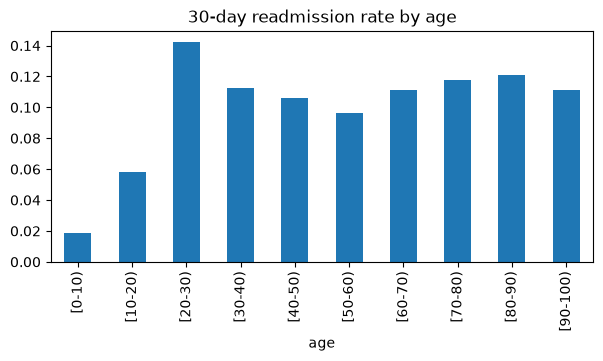

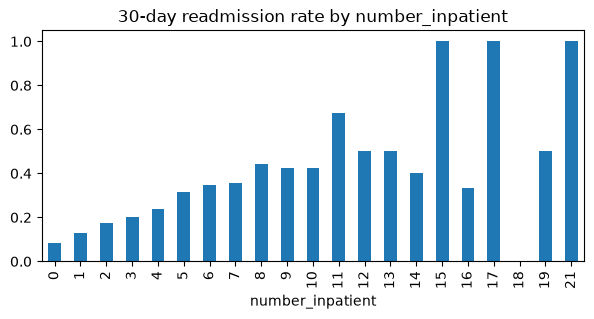

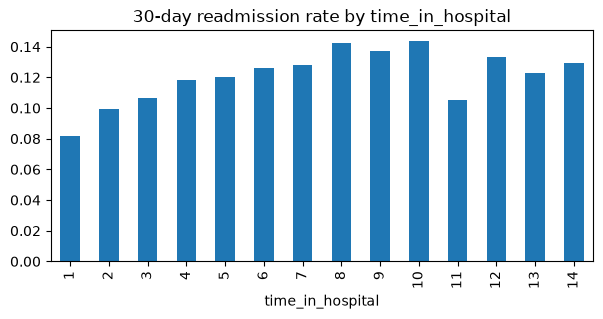

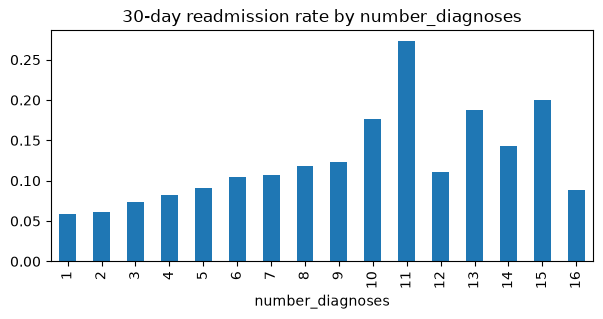

In [15]:
for col in ["age", "number_inpatient", "time_in_hospital", "number_diagnoses"]:
    rate = df.groupby(col)[config.TARGET].mean()
    rate.plot(kind="bar", title=f"30-day readmission rate by {col}", figsize=(7, 3))
    plt.show()

In [16]:
unknown_codes = {
    "admission_type_id": [5, 6, 8],
    "discharge_disposition_id": [18, 25, 26],
    "admission_source_id": [9, 15, 17, 20, 21],
}
for col, codes in unknown_codes.items():
    print(f"{col}: {df[col].isin(codes).mean():.1%} of encounters have an unknown/unmapped code")

admission_type_id: 10.2% of encounters have an unknown/unmapped code
discharge_disposition_id: 4.6% of encounters have an unknown/unmapped code
admission_source_id: 6.9% of encounters have an unknown/unmapped code


## Unknown / unmapped codes
Three ID columns contain "Not Available / NULL / Not Mapped" codes: 10.2% of encounters in
`admission_type_id`, 4.6% in `discharge_disposition_id` and 6.9% in `admission_source_id`.
They will be grouped into a single "Unknown" category instead of being dropped, since the rows
are otherwise valid.

In [17]:
for col in ["age", "number_inpatient", "time_in_hospital", "number_diagnoses"]:
    g = df.groupby(col)[config.TARGET].agg(rate="mean", n="size")
    print(f"--- {col}: categories with fewer than 200 encounters")
    print(g[g["n"] < 200])

--- age: categories with fewer than 200 encounters
            rate    n
age                  
[0-10)  0.018634  161
--- number_inpatient: categories with fewer than 200 encounters
                      rate    n
number_inpatient               
8                 0.443709  151
9                 0.423423  111
10                0.426230   61
11                0.673469   49
12                0.500000   34
13                0.500000   20
14                0.400000   10
15                1.000000    9
16                0.333333    6
17                1.000000    1
18                0.000000    1
19                0.500000    2
21                1.000000    1
--- time_in_hospital: categories with fewer than 200 encounters
Empty DataFrame
Columns: [rate, n]
Index: []
--- number_diagnoses: categories with fewer than 200 encounters
                      rate   n
number_diagnoses              
10                0.176471  17
11                0.272727  11
12                0.111111   9
13         

## Readmission rate by variable
- `number_inpatient` (prior inpatient visits) is the strongest signal: the rate grows from ~8%
  with no prior visits to 30–45% with 5 or more.
- `time_in_hospital` shows a mild positive trend (~8% at 1 day, ~14% at 8–10 days). All of its
  values have more than 200 encounters.
- `number_diagnoses` increases up to ~9 diagnoses; beyond that the rate is erratic.
- `age` is mostly flat across adult groups; `[0-10)` has only 161 encounters.

**Caution — sparse categories.** `number_inpatient` ≥ 8 covers only 456 encounters in total
(~0.4%), and above 11 each value has fewer than 50, which explains the 0% and 100% bars
(e.g. 100% at 15 with n=9, and at 17 and 21 with n=1). `number_diagnoses` ≥ 10 covers just 115
encounters, with rates jumping between 9% and 27%. These rates are noise, not signal.
Decision: cap `number_inpatient` at "8+" and `number_diagnoses` at "10+" for the linear baseline,
and consider merging the youngest age groups (0–30).

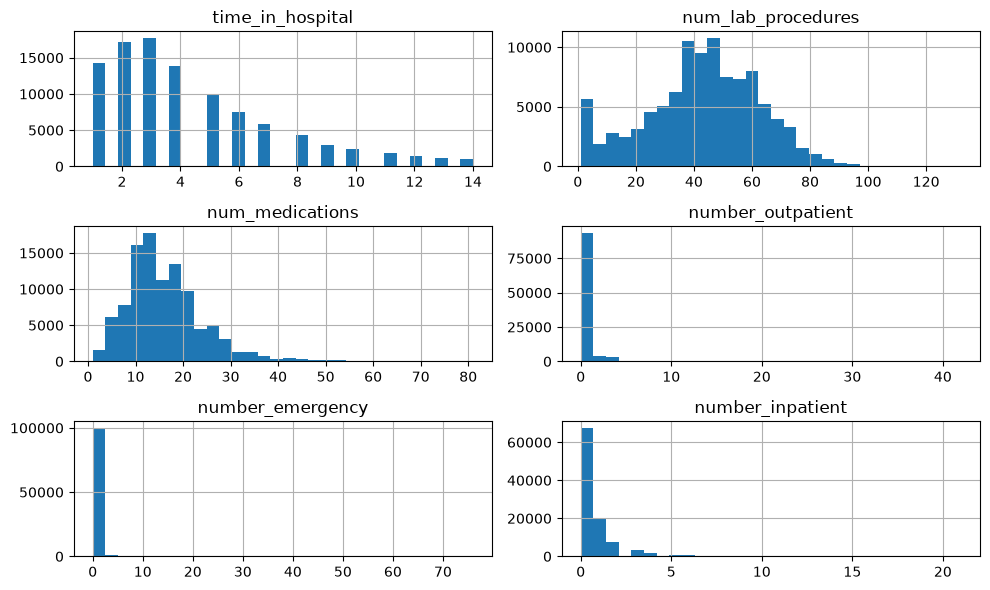

In [18]:
num_cols = ["time_in_hospital", "num_lab_procedures", "num_medications",
            "number_outpatient", "number_emergency", "number_inpatient"]
df[num_cols].hist(bins=30, figsize=(10, 6))
plt.tight_layout()

## Numeric distributions
Time in hospital, number of medications and the three visit counters are strongly right-skewed.
Tree-based models can handle this as is; for the logistic regression baseline I will apply a
log transform or clip at the 99th percentile. A combined feature
(`outpatient + emergency + inpatient`) is worth testing.

## Conclusions and next steps (data cleaning)
1. Split train/test by patient (`patient_nbr`).
2. Exclude death/hospice discharges (codes 11, 13, 14, 19, 20, 21, verified against `IDS_mapping.csv`).
3. Drop `weight`, encounter/patient IDs and `race` (as a feature); `?` is missing, `None` is a category.
4. Treat `admission_type_id`, `discharge_disposition_id` and `admission_source_id` as categorical,
   grouping unmapped codes as "Unknown".
5. Cap sparse counts (`number_inpatient` 8+, `number_diagnoses` 10+); add a prior-visits feature.
6. Check near-constant columns (e.g. some medication columns) with `nunique()` and drop them.
7. Evaluate with AUC-PR, recall and calibration; report by subgroup.